## Code of System
***
Код системы

### **imports**
Installing libraries
---
***
Установка библиотек

In [45]:
from IPython.display import clear_output

!pip3 install langgraph
!pip3 install -U langchain-google-genai
!pip3 install -U langchain-groq

clear_output(wait=False)

In [46]:
from typing import TypedDict, List, Annotated, Literal
from langgraph.graph.message import add_messages
from pandas.api.types import is_numeric_dtype

from langgraph.graph import StateGraph, START, END
from langgraph.graph import StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from pydantic import BaseModel, Field
from langgraph.types import Command

import pandas as pd
import json

import matplotlib.pyplot as plt
import seaborn as sns
import io
import PIL.Image
from scipy.stats import probplot
from scipy.stats import shapiro
import google.generativeai as genai

from langgraph.types import interrupt
from langchain_core.rate_limiters import InMemoryRateLimiter

### Initialization LLM
Инициализация большой языковой модели

In [47]:
def make_llm_gemini(api):
    rate_limiter = InMemoryRateLimiter(
        requests_per_second=15,
        check_every_n_seconds=0.1,
        max_bucket_size=15
    )
    llm = ChatGoogleGenerativeAI(
        model='models/gemini-2.5-flash-lite',
        google_api_key=api,
        rate_limiter=rate_limiter,
        max_retries=5
    )

    return llm

def make_llm_groq(api):
    rate_limiter = InMemoryRateLimiter(
        requests_per_second=15,
        check_every_n_seconds=0.1,
        max_bucket_size=15
    )

    llm = ChatGroq(
        model='llama-3.3-70b-versatile',
        api_key=api,
        temperature=0.1,
        rate_limiter=rate_limiter,
        max_retries=5
    )

    return llm


In [ ]:
models = {
    'llm_groq_1': make_llm_groq('')
    , 'llm_groq_2': make_llm_groq('')
    , 'llm_gemini_1': make_llm_gemini(api='')
    , 'llm_gemini_2': make_llm_gemini(api='')

}

### State of Graph
***
Состояние графа

In [49]:
class UserState(TypedDict):
    messages: Annotated[list, add_messages] # - conversation history
    # - диалог
    data: pd.DataFrame                      # - dataset
    # - датасет

    target: str                             # - target variable
    # - целевая переменная
    grouping_variable: str                  # - grouping variable
    # - группирующая переменная
    grouping_values: List[str]              # - grouping variable values
    # - значения групповой переменной

    user_response: str

    is_fraud: bool

    satisfied: str                          # - state of selected variables
    # - состояние выбронных переменных
    is_normal_target: bool                  # - whether the target distribution is normal
    # - нормальное ли распределен таргет

    samples: List[str]                      # - groups for the statistical test
    # - группы для стат теста

    target_dtype: str                       # - target variable data type
    # - тип целевой переменной
    grouping_variable_dtype: str            # - grouping variable data type
    # - тип группирующей переменной

    method_of_var_analisis: str             # - variance analysis method
    # - метод дисперсионного анализа**

    artefacts: List[str]                    # - artifacts to be passed to the LLM for summary generation
    # - артефакты, все что будет переданно в llm для вывода сводки

    summary: str                            # - research summary
    # - сводка исследования

### Definition of main variables
***
Определение главных переменные

In [50]:
class TargetExtraction(BaseModel):
    target: str = Field(description='Название зависимой переменной. По которой будет производиться стат тест. Тип может быть любой.')
    grouping_variable: str = Field(description='Группирующая переменная. Если подразумеватеся проверка нескольких групп, рекомендуется использовать одну переменную. Тип может быть любой.')
    grouping_values: List[str] = Field(description='Значения, разделюящие группирующую переменную на выборки (в том числе и какие-то значение числовой переменной, НО передавать строго списком, из str значений). Также тут можем быть СПИСОК с одним значением "ALL", если к примеру, необходимо провести анализ взаимосвязи двх количественных переменных.')

def find_variables(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']
    model_name = config.get('configurable', {}).get('model_name', 'llm_groq_1')
    llm = models[model_name]

    data = state['data'].copy()
    date_cols = data.select_dtypes(include=['datetime', 'datetimetz']).columns
    data[date_cols] = data[date_cols].astype(str)

    bool_cols = data.select_dtypes(include=['bool']).columns
    data[bool_cols] = data[bool_cols].astype(int)

    all_counts = {}
    num_cols = len(data.columns)

    for col in data.columns:
        top_n = 1 if num_cols > 150 else 10

        counts = data[col].value_counts().head(top_n).to_dict()

        unique_count = data[col].nunique()
        if unique_count > top_n:
            counts['...'] = f'and {unique_count - top_n} more'

        all_counts[col] = counts

    sys_prompt = f'Ты помощник аналитика. По сообщению пользователя, тебе необходимо определить значения зависимой переменной и группирующей. Исходи из того, что хочет пользователь.'\
                f'Вот данные, пользователя. dtypes: {data.dtypes.to_string()}\nvalues counts: {json.dumps(all_counts, ensure_ascii=False, indent=2)}'

    messages = state['messages']
    instruction = HumanMessage(content='Внимательно изучи последние системные сообщения об ошибках и исправь свой выбор переменных согласно им. Не повторяй предыдущие ошибки.')

    structured_llm = llm.with_structured_output(TargetExtraction)

    result = structured_llm.invoke([sys_prompt] + messages + [instruction])

    msg = f'Выбран таргет: {result.target}, групповая переменная: {result.grouping_variable}, ее значения: {' '.join(result.grouping_values)}\n\nВас удовлетворяет выбор?'
    send_msg(chat_id, msg)

    return {
        'target': result.target
        , 'grouping_variable': result.grouping_variable
        , 'grouping_values': result.grouping_values
        , 'satisfied': None
        , 'data': data
    }

In [51]:
def is_not_fraud(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    is_fraud = state['is_fraud']

    if is_fraud:
        send_msg(chat_id, 'Ваш запрос был определен системой как фрод. Рекомендумаем сменить его и попробовать сново позднее.')
        return 'FRAUD'
    else:
        return 'PASS'

In [52]:
def wait_step(state: UserState) -> UserState:
    res = interrupt('resp')
    return {'user_response': res}

In [53]:
class CorrectingVariables(BaseModel):
    answer: Literal['YES', 'NO'] = Field(description='Выбор удовлетворил пользователя? Толко YES или NO')
    correction_message: str = Field(description='Опиши переменные которые пользователь хочет поменять и на что, а какие хочет оставить. Если пользователя все устроило, оставь пробел.')

def is_correct_variables(state: UserState, config):
    response = state['user_response']
    model_name = config.get('configurable', {}).get('model_name', 'llm_groq_1')
    llm = models[model_name]

    structured_llm = llm.with_structured_output(CorrectingVariables)
    analysis = structured_llm.invoke(
        f'Пользователь ответил на выбор переменных.\n'
        f'Выбрано: target={state['target']}, group={state['grouping_variable']}.\n'
        f'Твоя задача, удовлетворен ли пользователем выбором переменных.\nОтвет пользователя: {response}.'
    )
    new_messages = state.get('messages', [])
    if analysis.answer == 'NO':
        feedback_msg = SystemMessage(content=f"ОШИБКА: Пользователь недоволен. Исправь выбор. {analysis.correction_message}")
        new_messages.append(feedback_msg)
    return {
        'satisfied': analysis.answer,
        'messages': new_messages
    }

### Preprocessing with mini LLM-agent
***
Предобработка с LLM агентом

In [54]:
def process_dtypes_strictly(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    data = state['data'].copy()
    t_col = state['target']
    g_col = state['grouping_variable']
    groups = state['grouping_values']
    q = 0

    artefact = f''

    for col in [t_col, g_col]:
        if col is None: continue

        unique_vals = set(data[col].dropna().unique())

        if unique_vals == {0, 1} or unique_vals == {0.0, 1.0}:
            data[col] = data[col].astype(str)
            msg = f'У {col} изменен тип на string (бинарная переменная).\n'
            artefact += msg

    if not is_numeric_dtype(data[t_col]) and is_numeric_dtype(data[g_col]) and groups[0] == 'ALL':
        t_col, g_col = g_col, t_col
        send_msg(chat_id, 'Произведена рокировка целевой и групповой переменных.')
        return {'data': data
                , 'target_dtype': str(data[t_col].dtype)
                , 'grouping_variable_dtype': str(data[g_col].dtype)
                , 'artefacts': state.get('artefacts', []) + [artefact]
                , 'target': t_col
                , 'grouping_variable': g_col
                , 'grouping_values': data[g_col].unique()}

    return {'data': data
            , 'target_dtype': str(data[t_col].dtype)
            , 'grouping_variable_dtype': str(data[g_col].dtype)
            , 'artefacts': state.get('artefacts', []) + [artefact]}

In [55]:
import ast
from typing import Optional

def change_dtype(data: pd.DataFrame, change_dtype_column: str, change_column_dtype: str) -> pd.DataFrame:
    try:
        data[change_dtype_column] = data[change_dtype_column].astype(change_column_dtype)
    except:
        print('some thing went wrong! -CNG')
    return data

def make_buckets(data: pd.DataFrame, buckets_column: str, buckets_str: Optional[str]) -> pd.DataFrame:
    if not buckets_str:
        return data
    try:
        data_orig = data.copy(deep=True)
        buckets = ast.literal_eval(buckets_str.strip())
        if not isinstance(buckets, list):
            print(f'Ожидался список, пришло: {type(buckets)}')
            return data
        labels = [f'{buckets[i]}-{buckets[i+1]}' for i in range(len(buckets)-1)]
        new_values = pd.cut(
            data[buckets_column],
            bins=buckets,
            labels=labels,
            include_lowest=True
        )
        if not new_values.isna().all():
            data[buckets_column] = new_values
        else:
            return data_orig, 0

    except (ValueError, SyntaxError) as e:
        print(f'Ошибка парсинга интервалов "{buckets_str}": {e}')
    except Exception as e:
        print(f'Непредвиденная ошибка: {e}')
    return data, 1

def make_groupby_and_agg(data: pd.DataFrame, grouping_by: str, agg_what: str, agg_func: str) -> str:
    try:
        cnt_data = data.copy()
        if agg_func in ['mean', 'sum', 'median']:
            cnt_data[agg_what] = pd.to_numeric(cnt_data[agg_what], errors='coerce')
        res = cnt_data.groupby(grouping_by, observed=True)[agg_what].agg(agg_func).reset_index()
        info_to_artefacts = str(res)
    except Exception as e:
        print(f'Something went wrong! -AGG: {e}')
        info_to_artefacts = 'ошибка в агрегации данных (Не имеет критических значений - все в норме).'
    return info_to_artefacts

In [56]:
from typing import Literal, Optional
from typing import Optional, Literal
from pydantic import BaseModel, Field

class PreprocessingExtraction(BaseModel):
    make_buckets: bool = Field(
        description='REQUIRED: Use JSON boolean true/false. True если нужно разбить на интервалы.'
    )
    buckets_column: Optional[str] = Field(
        default=None,
        description='Название колонки для интервалов.'
    )
    buckets: Optional[str] = Field(
        default=None,
        description='Интервалы списком, например: "[0, 10, 20]". Нельзя использовать знаки ("-") исключительно, крайние точки интервалов!"'
    )

    change_dtype: bool = Field(
        description='REQUIRED: Use JSON boolean true/false. True если нужно сменить тип данных.'
    )
    change_dtype_column: Optional[str] = Field(
        default=None,
        description='Название колонки для смены типа.'
    )
    change_column_dtype: Optional[Literal['int', 'float', 'datetime', 'str']] = Field(
        default=None,
        description='Целевой тип данных.'
    )
    make_groupby_and_agg: bool = Field(
        description='REQUIRED: Use JSON boolean true/false. True если нужно сгруппировать данные и после сагрегировать'
    )
    grouping_by: Optional[str] = Field(
        default=None,
        description='Название колонки для группировки данных'
    )
    agg_what: Optional[str] = Field(
        default=None,
        description='Название колонки (после группировки) для агрегации данных'
    )
    agg_func: Optional[str] = Field(
        default=None,
        description='Функция, для агрегации (mean, min, max)'
    )

def make_preprocessing(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']
    model_name = config.get('configurable', {}).get('model_name', 'llm_groq_1')
    llm = models[model_name]

    data = state['data'].copy()

    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']

    all_counts = {}
    num_cols = len(data.columns)

    for col in data.columns:
        top_n = 1 if num_cols > 150 else 10

        counts = data[col].value_counts().head(top_n).to_dict()

        unique_count = data[col].nunique()
        if unique_count > top_n:
            counts['...'] = f'and {unique_count - top_n} more'

        all_counts[col] = counts

    sys_prompt = f'Определи, какой тип предобработки требуется для данных.\n'\
                 f'head: {data.head()}\n describe: {data.describe()}\n value-counts: {json.dumps(all_counts, ensure_ascii=False, indent=2)}\n'\
                 f'Согласованные с пользователем таргет: {target}, группирующая переменная: {grouping_variable}, ее значения: {grouping_values}\n'\
                 f'Так, смена типа данных необходима тогда, и только тогда, если того требует пользователь, либо без этого нельзя реализовать анализ (количественные данные но представленны строкой к примеру).\n'\
                 f'ИСПОЛЬЗОВАТЬ, АККУРАТНО: Реализация бакетов (интервалов), реализуется тогда и только тогда, если пользователь требует рассмотреть более общие группы, либо требует непосредственно реализации интервалов. '\
                 f'Никогда не используется в иных случаях, и если того не требует польщователь. При необзодимости сравнить конктреные значения КАТЕГОРИЧЕСКИ запрещенно использовать.\n'\
                 f'Также есть функция агрегации, она поможет сделать некие выводы, однако исходные данные она не меняет! Рекомендуется использовать если в данных есть количественная переменная.'
    messages = state['messages']
    instruction = HumanMessage(content='Внимательно изучи диалог, и ответь на вопрос.')
    structured_llm = llm.with_structured_output(PreprocessingExtraction)

    result = structured_llm.invoke([sys_prompt] + messages + [instruction])

    artefacts = f''

    if result.change_dtype:
        send_msg(chat_id, 'Меняю тип данных!')
        data = change_dtype(data, result.change_dtype_column, result.change_column_dtype)
        artefacts += f'Был сменен тип данных у {result.change_dtype_column}, на {result.change_column_dtype}'

    if len(grouping_values) <= 3 and grouping_values[0] != 'ALL':
        data[grouping_variable] = data[grouping_variable].astype(str)

    if result.make_buckets:
        res = make_buckets(data, result.buckets_column, result.buckets)
        if res[1]:
            data = res[0]
            send_msg(chat_id, 'Реализовываю интервалы!')
            artefacts += f'Были реализованны интервалы для переменной {result.buckets_column}, {result.buckets}'

    if result.make_groupby_and_agg:
        send_msg(chat_id, 'Делаю агрегацию!')
        info = make_groupby_and_agg(data, result.grouping_by, result.agg_what, result.agg_func)
        artefacts += f'Была реализованна группировка данных по {result.grouping_by} для переменной {result.agg_what}, с функцией {result.agg_func}. Результат: {info}. Далее работа по НЕ Агрегированным данным!'

    return {'data': data
            , 'artefacts': state.get('artefacts', []) + [artefacts]}

### Cleaning data
***
Очистка данных

In [57]:
def is_val_in_data(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    grouping_values = state['grouping_values']

    if 'ALL' in grouping_values:
        return 'YES'

    data_values = set(state['data'][state['grouping_variable']])
    is_subset = set(grouping_values).issubset(data_values)

    if is_subset:
        return 'YES'
    else:
        send_msg(chat_id, 'Некоторые из выбранных значений отсутствуют в данных.')
        return 'NO'
    return 'NO'

In [58]:
import numpy as np
from statsmodels.stats.stattools import medcouple

def cleaning_target(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    group_var = state['grouping_variable']

    notes = []

    def get_adjusted_bounds(series):
        x = series.dropna().values
        if len(x) < 5:
            return series.min(), series.max()

        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        mc = medcouple(x)

        if mc >= 0:
            low = q1 - 1.5 * np.exp(-4 * mc) * iqr
            high = q3 + 1.5 * np.exp(3 * mc) * iqr
        else:
            low = q1 - 1.5 * np.exp(-3 * mc) * iqr
            high = q3 + 1.5 * np.exp(4 * mc) * iqr
        return low, high

    if data[target].dtype in ['float64', 'int64']:
        if data[target].isna().any():
            data = data.dropna(subset=[target])
            notes.append(f"Удалены пропуски в таргете '{target}'")

        low, high = get_adjusted_bounds(data[target])
        before_cnt = len(data)
        data = data[(data[target] >= low) & (data[target] <= high)]
        notes.append(f"Таргет '{target}': удалено {before_cnt - len(data)} выбросов ({low:.2f} - {high:.2f})")
    else:
        if data[target].isna().any():
            data[target] = data[target].fillna('not set')
            notes.append(f"Пропуски в номинативном таргете '{target}' заменены на 'not set'")

    if data[group_var].dtype in ['float64', 'int64']:
        low, high = get_adjusted_bounds(data[group_var])
        before_cnt = len(data)
        data = data[(data[group_var] >= low) & (data[group_var] <= high)]
        notes.append(f"Группировка '{group_var}': удалено {before_cnt - len(data)} выбросов ({low:.2f} - {high:.2f})")

    final_artefact = " | ".join(notes) if notes else "Очистка не потребовалась"

    return {
        'data': data,
        'artefacts': state.get('artefacts', []) + [final_artefact]
    }

### Node for transition to stat tests
***
Узел перехода к стат тестам

In [59]:
def identifying_variables(state: UserState) -> UserState:
    # target & grouping_variable
    data = state['data'].copy()
    groups = state['grouping_values']

    target = state['target']
    grouping_variable = state['grouping_variable']

    len_of_groups = len(groups)
    if len_of_groups == 1 or len_of_groups == 2:
        if is_numeric_dtype(data[target]) and is_numeric_dtype(data[grouping_variable]):
            if groups[0] == 'ALL':
                print(f'две количественные!')
                return 'ALL_NUMERIC' # две количественные
            else:
                print(f'одна номинативная друга количественная!')
                return 'ONE_NUMERIC_AND_ONE_NOMINATIV' # одна номинативная друга количественная
        elif not is_numeric_dtype(data[target]) and not is_numeric_dtype(data[grouping_variable]):
            print(f'обе номинативные!')
            return 'ALL_NOMINATIV' # обе номинативные
        elif is_numeric_dtype(data[target]) and not is_numeric_dtype(data[grouping_variable]):
            print(f'одна номинативная друга количественная')
            return 'ONE_NUMERIC_AND_ONE_NOMINATIV' # одна номинативная друга количественная
    else:
        if is_numeric_dtype(data[target]):
            print(f'таргет количественный!')
            return 'MANY_GROUPS_AND_NUMERIC_TARGET' # таргет количественный
        elif not is_numeric_dtype(data[target]):
            print(f'таргет номинативный!')
            return 'MANY_GROUPS_AND_NOMINATIV_TARGET' # таргет номинативный

### Both variables are numeric
***
Обе переменные количественные

In [60]:
# identifying_variables -> ALL_NUMERIC
import statsmodels.api as sm
from scipy.stats import pearsonr
from scipy.stats import spearmanr

def make_lin_reg(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    data = state['data'].copy()
    x = sm.add_constant(data[state['grouping_variable']])
    y = data[state['target']]
    model = sm.OLS(y, x).fit()
    artefact = f'По скольку в выбранных переменных обе переменные количественные, построим линейную регрессию. Сводка (summary):\n{str(model.summary())}'
    send_msg(chat_id, 'Cтрою линейную регрессию!')
    return {'artefacts': state.get('artefacts', []) + [artefact]}

def make_corrs(state: UserState) -> UserState:
    data = state['data']
    pr_stat, _ = pearsonr(data[state['target']], data[state['grouping_variable']])
    sp_stat, _ = spearmanr(data[state['target']], data[state['grouping_variable']])
    artefact = f'Построим корреляции между признаками, pearson: {pr_stat}, spearman: {sp_stat}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

### Both variables are nominative
***
Обе переменные номинативные

In [61]:
# identifying_variables -> ALL_NOMINATIV
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact

def make_chi2(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    data = state['data'].copy()
    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']

    if len(grouping_values) == 1 and grouping_values[0] == 'ALL':
        contingency_table = pd.crosstab(data[target], data[grouping_variable])
    else:
        data = data[data[grouping_variable].isin(grouping_values)]
        if len(grouping_values) == 1:
            return {'artefacts': state.get('artefacts', []) + [f'Так, как исследуется только одно уникальное значение, была реализована агрегация: {data.groupby(grouping_variable)['target'].mean()}']}
        contingency_table = pd.crosstab(data[target], data[grouping_variable])

    res = chi2_contingency(contingency_table)
    send_msg(chat_id, 'Уже проверию Хи квадратом Пирсона!')
    artefact = f'Был проведен анализ таблицы сопряженности, вот таблица: {contingency_table}, вот результат (Хи-квадрат): {res}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

def make_fisher_exact(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    grouping_variable = state['grouping_variable']

    grouping_values = state['grouping_values']

    if len(grouping_values) == 1 and grouping_values[0] == 'ALL':
        contingency_table = pd.crosstab(data[target], data[grouping_variable])
    else:
        data = data[data[grouping_variable].isin(grouping_values)]
        if len(grouping_values) == 1:
            return {'artefacts': state.get('artefacts', []) + [f'Так, как исследуется только одно уникальное значение, была реализована агрегация: {data.groupby(grouping_variable)['target'].mean()}']}
        contingency_table = pd.crosstab(data[target], data[grouping_variable])

    res = fisher_exact(contingency_table)
    artefact = f'Также был проведен точный критерий фишера: {res}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

### One variable is quantitative, the second is nominative
***
Одна переменная количественная, вторая номинативная

In [62]:
import scipy
from scipy.stats import shapiro, norm, gaussian_kde

# identifying_variables -> ONE_NUMERIC_AND_ONE_NOMINATIV
def is_normal_distribution(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    data = state['data'].copy()
    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']

    if not is_numeric_dtype(data[grouping_variable]):
        sample_one = data[data[grouping_variable] == grouping_values[0]][target].dropna().to_numpy()
        sample_two = data[data[grouping_variable] == grouping_values[1]][target].dropna().to_numpy()
    else:
        sample_one = data[data[grouping_variable] <= float(grouping_values[0])][target].dropna().to_numpy()
        sample_two = data[data[grouping_variable] > float(grouping_values[0])][target].dropna().to_numpy()

    samples = [sample_one, sample_two]
    group_names = [f"Группа {grouping_values[0]}", f"Группа {grouping_values[1]}"]

    results_is_normal = []
    total_artefacts = state.get('artefacts', [])

    for i, sample in enumerate(samples):
        n_obs = len(sample)
        stat, pval = shapiro(sample)

        if pval > 0.05:
            artefact = f'В группе {group_names[i]} признак {target} распределен нормально (Шапиро-Уилк, pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально)'
            total_artefacts.append(artefact)
            results_is_normal.append(True)
            continue
        send_msg(chat_id, 'Оцениваю схожесть с нормальным распределением!')

        std_sample = (sample - np.mean(sample)) / (np.std(sample, ddof=1) + 1e-9)
        x = np.linspace(-4, 4, 100)

        try:
            kde = gaussian_kde(std_sample)
            pk = kde.evaluate(x) + 1e-9
            qk = norm.pdf(x) + 1e-9

            pk /= np.sum(pk)
            qk /= np.sum(qk)

            kl_dist = scipy.stats.entropy(pk, qk)
            skew = scipy.stats.skew(sample, bias=False)

            threshold = 0.055
            answer_is_normal = kl_dist < threshold and abs(skew) < 0.8

            justification = (f"Форма распределения (KL-dist={kl_dist:.3f}) "
                             f"{'близка к колоколу' if answer_is_normal else 'сильно искажена'}. "
                             f"Асимметрия: {skew:.2f}. "
                             f"Учтена ЦПМ: при N={n_obs} небольшие отклонения допустимы.")

        except:
            answer_is_normal = False
            justification = "Не удалось корректно оценить форму распределения (возможны выбросы или малая выборка)."

        results_is_normal.append(answer_is_normal)

        status_text = 'Нормально' if answer_is_normal else 'Ненормально'
        if answer_is_normal:
            send_msg(chat_id, 'Распределение нормально! Иду далее...')

        artefact = f'Визуальный анализ показал что признак, {group_names[i]}: распределен: {status_text}. Тест показал: (Шапиро-Уилк pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально). Обоснование: {justification}'
        total_artefacts.append(artefact)

        if not results_is_normal[-1]:
            send_msg(chat_id, 'Используем непараметрические методы!')
            break

    final_is_normal = all(results_is_normal) and len(results_is_normal) == len(samples)

    return {
        'is_normal_target': final_is_normal,
        'artefacts': total_artefacts
    }

In [63]:
def make_samples(state: UserState) -> UserState:
    data = state['data']
    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']
    total_artefacts = state.get('artefacts', [])

    if not is_numeric_dtype(data[grouping_variable]):
        sample_one = data[data[grouping_variable] == grouping_values[0]]
        sample_two = data[data[grouping_variable] == grouping_values[1]]
    else:
        sample_one = data[data[grouping_variable] <= float(grouping_values[0])]
        sample_two = data[data[grouping_variable] > float(grouping_values[1])]
    samples = [sample_one[target].to_numpy(), sample_two[target].to_numpy()]

    total_artefacts.append(f'Первой (левой, с которой сравниваем) выборкой является значение групповой переменно: {grouping_values[0]}, второй соответственно: {grouping_values[1]}')

    return {'samples': samples, 'artefacts': total_artefacts}

In [64]:
from scipy.stats import levene
def choose_stat_test(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']
    is_normal_target = state['is_normal_target']

    if is_normal_target:
        stat, pval = levene(sampl1, sampl2)
        if pval > 0.05:
            return 'T_TEST'
        else:
            return 'WELCH_T_TEST'
    else:
        return 'MANAYITHUI'

In [65]:
from scipy.stats import ttest_ind
def make_ttest(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']

    stat, pval = ttest_ind(sampl1, sampl2)

    artefact = f'Так как признак распределен нормально, и выборочные дисперсии равны (тест Левенне), мы проводим t-test, его результат: stat-{stat}, pval-{pval}. Разница средних sample_1 - sample_2 = {sampl1.mean() - sampl2.mean()}'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [66]:
def make_welch_ttest(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']

    stat, pval = ttest_ind(sampl1, sampl2, equal_var=False)

    artefact = f'Так как признак распределен нормально, и выборочные дисперсии не равны (тест Левенне), мы проводим t-test welch-а, его результат: stat-{stat}, pval-{pval}. Разница средних sample_1 - sample_2 = {sampl1.mean() - sampl2.mean()}'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [67]:
def make_manayithui(state: UserState):
    print('Применяю стат тест!')
    return

In [68]:
import numpy as np
def choose_method_to_make_manayithui(state: UserState) -> UserState:
    sampl1, sampl2 = state['samples']
    bakets1 = np.array_split(sampl1, 500)
    bakets2 = np.array_split(sampl2, 500)

    if len(bakets1[0]) < 10 or len(bakets2[0]) < 10:
        return 'STANDART_MANAYITHUI'
    else:
        return 'BAKET_MANAYITHUI'

In [69]:
from scipy.stats import mannwhitneyu
def make_standart_manayithui(state: UserState):
    sampl1, sampl2 = state['samples']
    stat, pval = mannwhitneyu(sampl1, sampl2)

    artefact = f'Так как признак распределен не нормально (Визуальный анализ и тест Шапиро Уилка) => используем стандартный стат тест Манна Уитни: stat-{stat}, pval-{pval}. Разница средних sample_1 - sample_2 = {sampl1.mean() - sampl2.mean()}'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [70]:
from scipy.stats import mannwhitneyu
def make_baket_manayithui(state: UserState):
    sampl1, sampl2 = state['samples']

    s1_shuffled = np.random.permutation(sampl1)
    s2_shuffled = np.random.permutation(sampl2)

    bakets1 = np.array_split(s1_shuffled, 500)
    bakets2 = np.array_split(s2_shuffled, 500)

    baket1 = np.mean(bakets1, axis=1)
    baket2 = np.mean(bakets2, axis=1)

    stat, pval = mannwhitneyu(baket1, baket2)

    artefact = f'Так как признак распределен не нормально (Визуальный анализ и тест Шапиро Уилка). А также данных достаточно для бакетизации.'\
                f'Мы случайным образом будем создавать бакеты по >10 наблюдения в каждом, считать среднее и после проводить тест Манна Уитни.'\
                f'Что даст устойчивости и мощности тесту. \nstat-{stat}, pval-{pval}.'

    return {'artefacts': state.get('artefacts', []) + [artefact]}

### Many groups and dependent numeric
***
Много групп и зависимая количественная

In [71]:
def is_normal_distribution_for_var(state: UserState, config):
    send_msg = config['configurable']['callback']
    chat_id = config['configurable']['thread_id']

    data = state['data'].copy()
    target = state['target']
    grouping_variable = state['grouping_variable']
    grouping_values = state['grouping_values']

    data = data[data[grouping_variable].isin(grouping_values)]

    total_artefacts = state.get('artefacts', [])
    results_is_normal = []

    for group_label in grouping_values:
        sample = data[data[grouping_variable] == group_label][target].dropna().to_numpy()

        if len(sample) < 3:
            results_is_normal.append(False)
            continue

        stat, pval = shapiro(sample)

        if pval > 0.05:
            artefact = f'Группа {group_label}: признак {target} распределен нормально (Шапиро-Уилк, pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально)'
            total_artefacts.append(artefact)
            results_is_normal.append(True)
            continue

        send_msg(chat_id, 'Визуально оцениваю схожесть с нормальным распределением!')

        skew = scipy.stats.skew(sample, bias=False)
        n_obs = len(sample)

        try:
            std_sample = (sample - np.mean(sample)) / (np.std(sample, ddof=1) + 1e-9)
            x = np.linspace(-4, 4, 100)

            kde = gaussian_kde(std_sample)
            pk = kde.evaluate(x) + 1e-9
            qk = norm.pdf(x) + 1e-9

            pk /= np.sum(pk)
            qk /= np.sum(qk)

            kl_dist = scipy.stats.entropy(pk, qk)

            threshold = 0.055
            answer_is_normal = kl_dist < threshold and abs(skew) < 0.8

            why_is_normsl = (f"Анализ формы (KL-dist={kl_dist:.3f}) показал, что распределение "
                             f"{'достаточно симметрично' if answer_is_normal else 'сильно деформировано'}. "
                             f"Асимметрия: {skew:.2f}. ЦПМ учтена: при N={n_obs} форма важнее p-value тестов.")
        except:
            answer_is_normal = False
            why_is_normsl = "Ошибка при анализе геометрии распределения. Возможно, данные слишком специфичны."

        results_is_normal.append(answer_is_normal)

        status_text = 'Нормально' if answer_is_normal else 'Ненормально'
        if answer_is_normal:
            send_msg(chat_id, 'Распределение нормально! Иду далее...')

        artefact = f'Группа {group_label}: визуальный анализ показал "{status_text}". (Шапиро-Уилк pval={pval:.4f}. Если больше 0.05 -> нормальное, тк H0 распределение нормально)\n\nОбоснование: {why_is_normsl}'
        total_artefacts.append(artefact)

        if not results_is_normal[-1]:
            send_msg(chat_id, 'Используем непараметрические методы!')
            break

    final_is_normal = all(results_is_normal) and len(results_is_normal) == len(grouping_values)

    return {
        'is_normal_target': final_is_normal,
        'artefacts': total_artefacts
    }


In [72]:
def choose_stat(state: UserState) -> UserState:
    # is_normal_distribution -> data
    if state['is_normal_target']:
        data = state['data'].copy()
        target = state['target']
        grouping_variable = state['grouping_variable']

        if is_numeric_dtype(data[grouping_variable]):
            grouping_values = state['grouping_values']
            values = data['target']
            indices = np.searchsorted(np.sort(grouping_values), values)
            samples = [values[indices == i] for i in range(len(grouping_values) + 1)]
        else:
            samples = [group[target].values for name, group in data.groupby(grouping_variable)]

        samples = [i for i in samples if len(i) > 0]

        stat, pval = levene(*samples)

        if pval > 0.05:
            return {'method_of_var_analisis': 'ANOVA'}
    return {'method_of_var_analisis': 'KRUSKAL'}

In [73]:
from scipy.stats import f_oneway
from scipy.stats import kruskal
def make_var_analisis(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    grouping_variable = state['grouping_variable']

    if is_numeric_dtype(data[grouping_variable]):
        grouping_values = state['grouping_values']
        values = data['target']
        indices = np.searchsorted(np.sort(grouping_values), values)
        samples = [values[indices == i] for i in range(len(grouping_values) + 1)]
    else:
        samples = [group[target].values for name, group in data.groupby(grouping_variable)]

    samples = [i for i in samples if len(i) > 0]
    if state['method_of_var_analisis'] == 'ANOVA':
        stat, pval = f_oneway(*samples)
    elif state['method_of_var_analisis'] == 'KRUSKAL':
        stat, pval = kruskal(*samples)

    artefact = f'Так как признак распределен {'нормально' if state['is_normal_target'] else 'ненормально'}, то был проведен стат тест - {state['method_of_var_analisis']}. Его результаты: stat-{stat}, pval-{pval}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

In [74]:
def make_ling_var_regression(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    group_var = state['grouping_variable']
    group_vals = state['grouping_values']

    if not is_numeric_dtype(data[group_var]):
        data = data[data[group_var].isin(group_vals)]

        data_encoded = pd.get_dummies(data[[target, group_var]], columns=[group_var], drop_first=True)

        data_encoded = data_encoded.astype(float)

        features = [col for col in data_encoded.columns if col != target]
        x = sm.add_constant(data_encoded[features])
        y = data_encoded[target]
    else:
        y = (data[target] > group_vals[0]).astype(float)
        x = sm.add_constant(data[group_var].astype(float))

    model = sm.OLS(y, x).fit()

    artefact = f'Была построенна линейная регрессия, вот ее сводка: {str(model.summary())}'
    return {'artefacts': state.get('artefacts', []) + [artefact]}

### Many groups and dependent nominative
***
Много групп и зависимая номинативная

In [75]:
def make_logit_regression(state: UserState) -> UserState:
    data = state['data'].copy()
    target = state['target']
    group_var = state['grouping_variable']
    group_vals = state['grouping_values']

    df = data.dropna(subset=[target, group_var])

    def prepare_and_fit(df):
        if not is_numeric_dtype(df[group_var]):
            x = pd.get_dummies(df[group_var], drop_first=True).astype(float)
            x = sm.add_constant(x)
            target_series = df[target]
        else:
            x = sm.add_constant(df[group_var].astype(float))
            target_series = df[target]

        unique_y = target_series.unique()

        if len(unique_y) == 2:
            y = pd.get_dummies(target_series, drop_first=True).iloc[:, 0].astype(float)
            return sm.Logit(y, x).fit(disp=0)
        else:
            y = target_series.astype('category').cat.codes
            return sm.MNLogit(y, x).fit(disp=0)

    try:
        model = prepare_and_fit(df)
        artefact = f'Была построенна логистическая регрессия, вот ее сводка: {str(model.summary())}'
        return {'artefacts': state.get('artefacts', []) + [artefact]}

    except Exception:
        try:
            data_reduced = df[df[group_var] != group_vals[-1]]
            model = prepare_and_fit(data_reduced)
            artefact = f'Построена регрессия после удаления одной группы: {str(model.summary())}'
            return {'artefacts': state.get('artefacts', []) + [artefact]}
        except Exception as e:
            artefact = f'Ошибка: {str(e)}'
            return {'artefacts': state.get('artefacts', []) + [artefact]}

### Summary
***
Сводка

**console version**

```python
def summary_by_llm(state: UserState) -> UserState:
    content = '\n'.join(state['artefacts'])

    prompt = (
    "Ты — ведущий аналитик системы автоматизированной проверки гипотез. "
    "Твоя цель: сформировать финальный отчет по итогам анализа для пользователя.\n\n"
    "### ИНСТРУКЦИЯ:\n"
    "Опирайся СТРОГО на предоставленные артефакты. Описывай только те этапы, которые фактически были выполнены.\n\n"
    "### ПЛАН ОТЧЕТА:\n"
    "1. **Суть исследования**: Сформулируй проверяемую гипотезу (H0 и H1).\n"
    "2. **Обработка данных**: Если проводилась очистка (IQR) или фильтрация — кратко опиши. Если данные использовались 'как есть' — пропусти этот пункт.\n"
    "3. **Статистическая проверка**: Назови выбранный критерий (например, t-test). ОБЯЗАТЕЛЬНО укажи, на основе каких свойств данных он был выбран (распределение, гомогенность дисперсий).\n"
    "4. **Результат**: Приведи p-value и сравни его с порогом значимости (0.05).\n"
    "5. **Заключение**: Дай четкий ответ — отвергаем мы H0 или нет, и есть ли статистически значимая разница.\n\n"
    "### СТИЛЬ:\n"
    "Сухой, экспертный, технически точный. Используй Markdown. Минимум 'воды', максимум конкретики из данных.\n\n"
    f"### АРТЕФАКТЫ И КОНТЕКСТ:\n{content}\n{state['messages']}"
    )

    response = llm.invoke(prompt)
    return {'summary': response.content}
```

In [76]:
def summary_by_llm(state: UserState, config):
    content = '\n'.join(state['artefacts'])
    model_name = config.get('configurable', {}).get('model_name', 'llm_groq_1')
    llm = models[model_name]

    prompt = (
    "Ты — ведущий аналитик системы автоматизированной проверки гипотез.\n"
    "Твоя цель: сформировать финальный отчет по итогам анализа для пользователя.\n\n"
    "### ИНСТРУКЦИЯ:\n"
    "Опирайся СТРОГО на предоставленные артефакты. Описывай только те этапы, которые фактически были выполнены.\n\n"
    "### ПЛАН ОТЧЕТА:\n"
    "1. **Суть исследования**: Сформулируй проверяемую гипотезу (H0 и H1). (Моноширинный шрифт, на разных строках. Максимально строго, желательно использовать фактические значения переменных (смотри в запросе пользователя), если это не получается, то названия колонок и соответствующих значений)\n"
    "2. **Обработка данных**: Если проводилась очистка или фильтрация — кратко опиши. При отсутствии, укажи на корректность данных для анализа.\n"
    "3. **Статистическая проверка**: Назови выбранный критерий (например, t-test). ОБЯЗАТЕЛЬНО укажи, на основе каких свойств данных он был выбран (распределение, гомогенность дисперсий).\n"
    "4. **Результат**: Приведи p-value (используй слово p-value или p-val. Старайся (если это возможно) немного округлять, для более легкого восприятия. Однако, без '0.0') и сравни его с порогом значимости (0.05).\n"
    "5. **Заключение**: Дай четкий ответ — отвергаем мы H0 или нет, и есть ли статистически значимая разница.\n"
    "6. **Вывод** (необязательный): Желательно, ответить на вопрос (гипотезу) пользователя. Требуется в явном виде сказать, что больше, а что меньше, если того требует польщователь\n\n"
    "### СТИЛЬ:\n"
    "Сухой, экспертный, технически точный. Используй Markdown. Минимум 'воды', максимум конкретики из данных.\n\n"
    "Вот используй только такую разметку:\n1. *Жирный текст*\n2. `Моноширинный шрифт`\nВАЖНО: Не используй для заголовков ### (решетку). Вместо этого делай заголовок *жирным шрифтом*.\n"
    "Также постарайся реше использовать названия колонок, используй ее смысл.\n\n"
    f"### АРТЕФАКТЫ И КОНТЕКСТ:\n{content}\nТут все взаимодействие с пользователем, можешь заимствоать названия для колонок от сюда:\n{state['messages']}"
    )

    response = llm.invoke(prompt)
    return {'summary': response.content}

### Graph structure
***
Структура графа

In [77]:
graph = StateGraph(UserState)

In [78]:
graph.add_node('find_variables', find_variables)

graph.add_node('wait_step', wait_step)

graph.add_node('is_correct_variables', is_correct_variables)

graph.add_node('correcting_dtypes', process_dtypes_strictly)

graph.add_node('make_preprocessing', make_preprocessing)

graph.add_node('cleaning_target', cleaning_target)

graph.add_node('make_lin_reg', make_lin_reg)
graph.add_node('make_corrs', make_corrs)

graph.add_node('make_chi2', make_chi2)
graph.add_node('make_fisher_exact', make_fisher_exact)

graph.add_node('is_normal_distribution', is_normal_distribution)

graph.add_node('make_samples', make_samples)

graph.add_node('make_ttest', make_ttest)
graph.add_node('make_welch_ttest', make_welch_ttest)
graph.add_node('make_manayithui', make_manayithui)
graph.add_node('make_standart_manayithui', make_standart_manayithui)
graph.add_node('make_baket_manayithui', make_baket_manayithui)

graph.add_node('choose_stat', choose_stat)
graph.add_node('is_normal_distribution_for_var', is_normal_distribution_for_var)
graph.add_node('make_var_analisis', make_var_analisis)
graph.add_node('make_ling_var_regression', make_ling_var_regression)

graph.add_node('make_logit_regression', make_logit_regression)

graph.add_node('summary_by_llm', summary_by_llm)

In [79]:
graph.add_edge(START, 'find_variables')

graph.add_edge('find_variables', 'wait_step')

graph.add_edge('wait_step', 'is_correct_variables')

graph.add_conditional_edges('is_correct_variables'
                            , lambda state: state['satisfied']
                            , {
                                'YES': 'correcting_dtypes'
                                , 'NO': 'find_variables'
                            })

graph.add_edge('correcting_dtypes', 'make_preprocessing')

graph.add_conditional_edges('make_preprocessing'
                            , is_val_in_data
                            , {
                                'YES': 'cleaning_target'
                                , 'NO': END
                            })

graph.add_conditional_edges('cleaning_target'
                            , identifying_variables
                            , {
                                'ALL_NUMERIC': 'make_lin_reg'
                                , 'ALL_NOMINATIV': 'make_chi2'
                                , 'ONE_NUMERIC_AND_ONE_NOMINATIV': 'is_normal_distribution'
                                , 'MANY_GROUPS_AND_NUMERIC_TARGET': 'is_normal_distribution_for_var'
                                , 'MANY_GROUPS_AND_NOMINATIV_TARGET': 'make_logit_regression'
                            })
graph.add_edge('make_lin_reg', 'make_corrs')
graph.add_edge('make_corrs', 'summary_by_llm')

graph.add_edge('make_chi2', 'make_fisher_exact')
graph.add_edge('make_fisher_exact', 'summary_by_llm')

graph.add_edge('is_normal_distribution', 'make_samples')

graph.add_conditional_edges('make_samples'
                            , choose_stat_test
                            , {
                                'T_TEST': 'make_ttest'
                                , 'WELCH_T_TEST': 'make_welch_ttest'
                                , 'MANAYITHUI': 'make_manayithui'
                            })
graph.add_edge('make_ttest', 'summary_by_llm')
graph.add_edge('make_welch_ttest', 'summary_by_llm')

graph.add_conditional_edges('make_manayithui'
                            , choose_method_to_make_manayithui
                            , {
                                'STANDART_MANAYITHUI': 'make_standart_manayithui'
                                , 'BAKET_MANAYITHUI': 'make_baket_manayithui'
                            })
graph.add_edge('make_standart_manayithui', 'summary_by_llm')
graph.add_edge('make_baket_manayithui', 'summary_by_llm')

graph.add_edge('is_normal_distribution_for_var', 'choose_stat')
graph.add_edge('choose_stat', 'make_var_analisis')
graph.add_edge('make_var_analisis', 'make_ling_var_regression')
graph.add_edge('make_ling_var_regression', 'summary_by_llm')

graph.add_edge('make_logit_regression', 'summary_by_llm')

## Usage
***
Использование

### **System interface**
***
Интерфейс системы

In [39]:
!pip3 install pyTelegramBotAPI

In [ ]:
import telebot
from telebot import types
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
from langgraph.types import Command
import pickle

bot = telebot.TeleBot('')

class PickleSerde(JsonPlusSerializer):
    def dumps_typed(self, obj):
        return ('pickle', pickle.dumps(obj))
    def loads_typed(self, data):
        raw_data = data[1] if isinstance(data, (list, tuple)) and len(data) > 1 else data
        return pickle.loads(raw_data)


memory = MemorySaver(serde=PickleSerde())

In [81]:
app = graph.compile(checkpointer=memory)

In [82]:
import threading
import re

class ModelPool:
    def __init__(self, model_configs):
        self.limits = model_configs
        self.models = {name: 0 for name in model_configs.keys()}
        self.cooldowns = {name: 0 for name in model_configs.keys()}
        self.lock = threading.Lock()

    def acquire_model(self):
        with self.lock:
            current_time = time.time()
            for model_name, current_load in self.models.items():
                if current_time < self.cooldowns[model_name]:
                    continue

                max_limit = self.limits.get(model_name, 0)
                if current_load < max_limit:
                    self.models[model_name] += 1
                    return model_name
            return None

    def is_everything_dead(self):
        with self.lock:
            current_time = time.time()
            return all(current_time < self.cooldowns[name] for name in self.limits.keys())


    def release_model(self, model_name):
        with self.lock:
            if model_name in self.models and self.models[model_name] > 0:
                self.models[model_name] -= 1

    def ban_by_error(self, model_name, error_message):
        with self.lock:
            if model_name not in self.cooldowns:
                return

            wait_time = 900
            match = re.search(r'try again in (?:(\d+)h)?(?:(\d+)m)?(?:([\d.]+)s)?', str(error_message))
            if match:
                hours = int(match.group(1) or 0)
                minutes = int(match.group(2) or 0)
                seconds = float(match.group(3) or 0)
                wait_time = (hours * 3600) + (minutes * 60) + seconds + 5

            self.cooldowns[model_name] = time.time() + wait_time
            self.models[model_name] = 0
            print(f"!!! Модель {model_name} забанена на {wait_time:.1f} сек. Причина: Rate Limit")

pool = ModelPool({
    'llm_groq_1': 10,
    'llm_groq_2': 10,
    'llm_gemini_1': 5,
    'llm_gemini_2': 5
})

In [83]:
import time
from threading import Lock

user_status = {}
lock = Lock()

@bot.message_handler(commands=['start'])
def start_command(message):
    chat_id = message.chat.id
    if chat_id not in user_status:
        user_status[chat_id] = {'count': 0, 'last_time': 0, 'processing': False}

    remains = 3 - user_status[chat_id]['count']
    bot.send_message(chat_id, f'Введите вашу гипотезу.\nДоступно исследований: {max(0, remains)}.')

@bot.message_handler(func=lambda message: True)
def handle_all_messages(message):
    chat_id = message.chat.id
    current_time = time.time()

    if chat_id not in user_status:
        user_status[chat_id] = {'count': 0, 'last_time': 0, 'processing': False}

    user = user_status[chat_id]

    if user['processing']:
        bot.send_message(chat_id, 'Анализ уже запущен...')
        return

    if user['count'] >= 3:
        bot.send_message(chat_id, 'Лимит исчерпан.')
        return

    time_passed = current_time - user['last_time']
    if user['last_time'] > 0 and time_passed < 15:
        wait_time = int(15 - time_passed)
        bot.send_message(chat_id, f'Подождите {wait_time} сек. перед следующим анализом.')
        return

    model_name = pool.acquire_model()

    if not model_name:
        if pool.is_everything_dead():
            bot.send_message(chat_id, 'Данная система работает на бесплатных API, и лимиты на них закончились. Попробуйте снова через ~15 мин')
        else:
            bot.send_message(chat_id, 'Все слоты заняты, подождите пару минут.')
        return

    with lock:
        user['processing'] = True

    try:
        current_thread_id = f"{chat_id}_{user['count']}"
        config = {
            'configurable': {
                'thread_id': current_thread_id
                , 'model_name': model_name
                , 'callback': bot.send_message
            }
        }

        state = app.get_state(config)
        if state.next:
            app.invoke(Command(resume=message.text), config=config)
        else:
            app.invoke({'messages': [message.text], 'data': sns.load_dataset('titanic')}, config=config)

        new_state = app.get_state(config)
        if not new_state.next:
            res = new_state.values.get('summary', 'Анализ завершен.')
            try:
                bot.send_message(chat_id, res, parse_mode='Markdown')
            except Exception as e:
                if "can't parse entities" in str(e):
                    bot.send_message(chat_id, res)
                else:
                    raise e
            user['count'] += 1
            user['last_time'] = time.time()

    except Exception as e:
        err_str = str(e)
        if "rate_limit_exceeded" in err_str or "429" in err_str:
            pool.ban_by_error(model_name, err_str)
            bot.send_message(chat_id, 'Лимиты модели закончились на вас, пожалуста повторите запрос снова.\n/start')
            user['count'] += 1
        else:
            print(f"Другая ошибка: {e}")
            bot.send_message(chat_id, 'Во время анализа произошла непредвиденная ошибка. Попробуйте снова позднее.')
    finally:
        pool.release_model(model_name)
        user['processing'] = False

In [84]:
bot.infinity_polling()

одна номинативная друга количественная
Применяю стат тест!


2026-05-02 08:39:34,414 (__init__.py:1134 MainThread) ERROR - TeleBot: "Infinity polling: polling exited"
ERROR:TeleBot:Infinity polling: polling exited
2026-05-02 08:39:34,416 (__init__.py:1136 MainThread) ERROR - TeleBot: "Break infinity polling"
ERROR:TeleBot:Break infinity polling


##test

Название             | KL       | Shapiro p  | Вердикт (0.06)
-----------------------------------------------------------------
1. Чистая норма      | 0.0046 | 2.8488e-01 | НОРМ
2. Легкий скос (a=2) | 0.0163 | 2.1279e-07 | НОРМ
3. Студента (df=5)   | 0.0165 | 2.9232e-13 | НОРМ
4. Почти ок (a=3)    | 0.0343 | 2.8707e-13 | НОРМ
5. Сильный скос (a=8) | 0.0760 | 1.6597e-19 | НЕ НОРМ
6. Равномерное       | 0.0683 | 4.5479e-16 | НЕ НОРМ
7. Бимодальное       | 0.1777 | 1.0616e-22 | НЕ НОРМ
8. Выбросы (Outliers) | 0.0244 | 1.1311e-30 | НОРМ


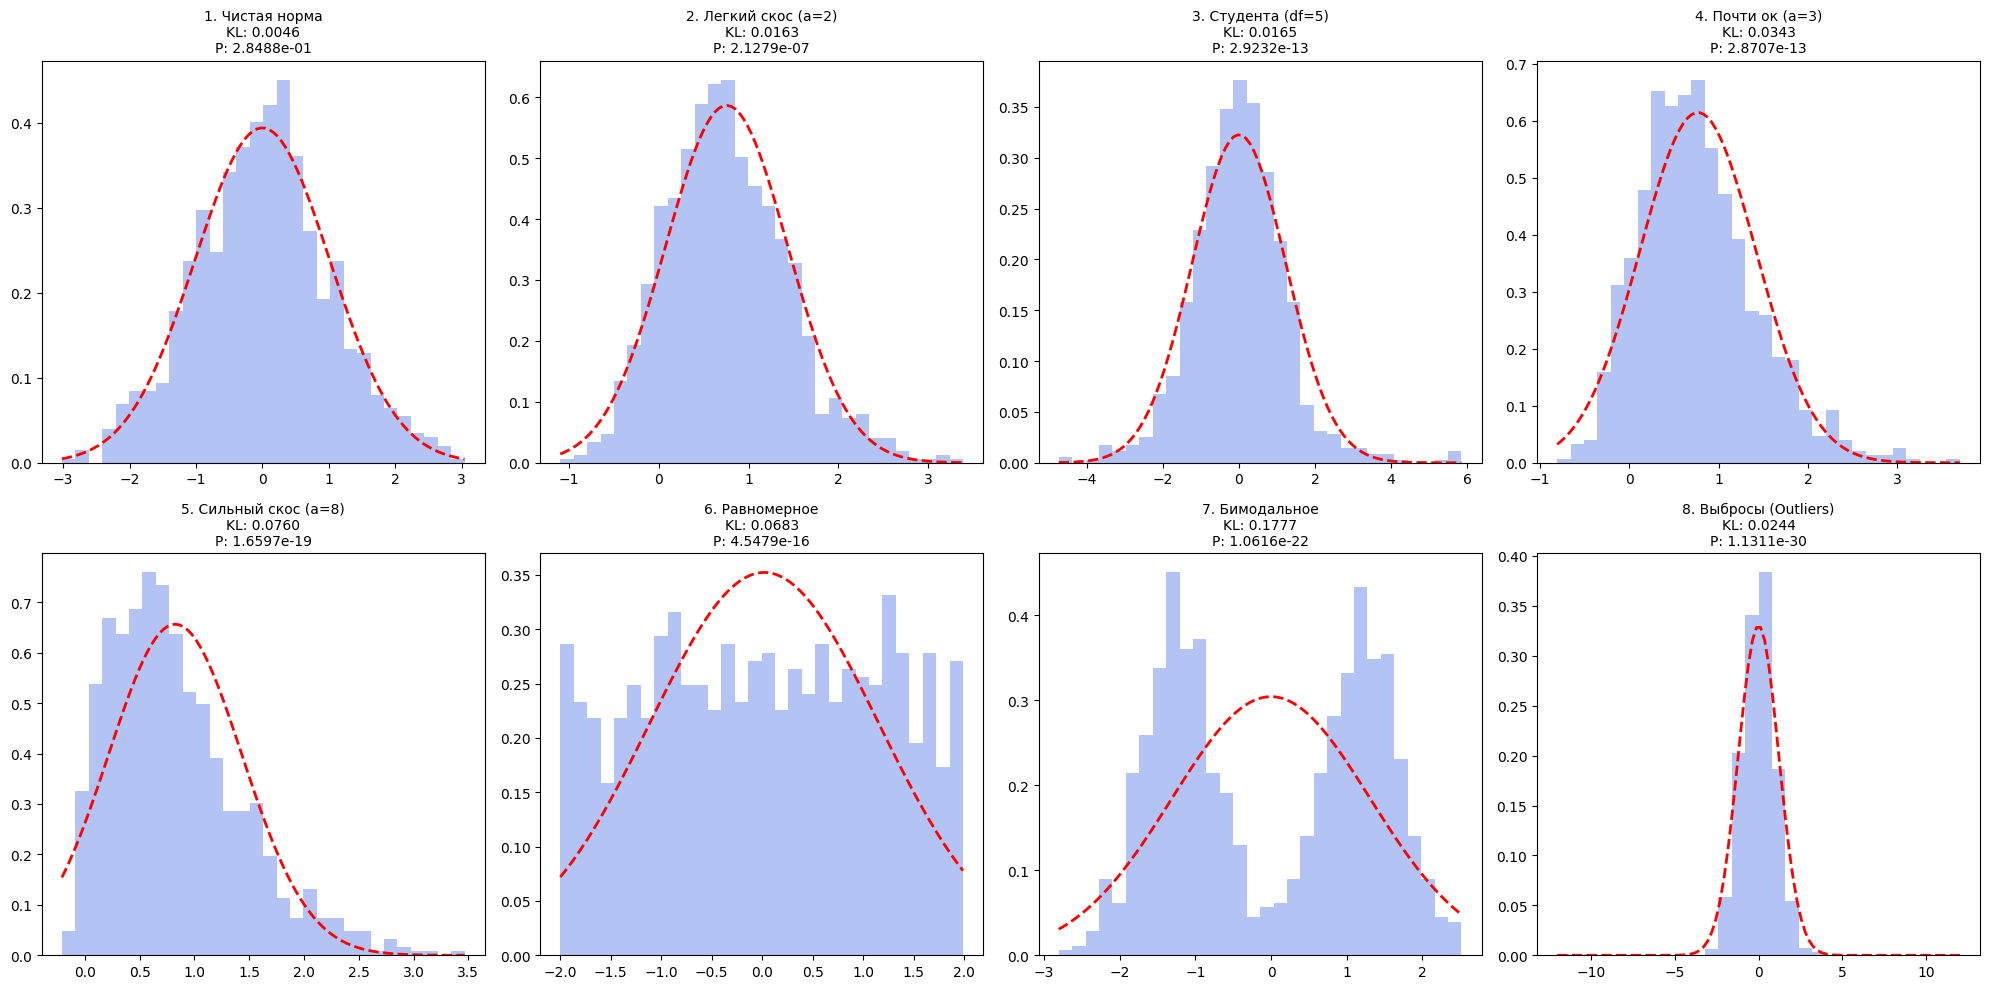

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def calculate_kl(sample):
    # Стандартизация
    std_sample = (sample - np.mean(sample)) / (np.std(sample, ddof=1) + 1e-9)
    x = np.linspace(-4, 4, 100)

    # Плотности
    kde = stats.gaussian_kde(std_sample)
    pk = kde.evaluate(x) + 1e-9
    qk = stats.norm.pdf(x) + 1e-9

    # Нормировка
    pk /= np.sum(pk)
    qk /= np.sum(qk)

    return stats.entropy(pk, qk)

# Генерация кучи разных распределений
n = 1000
samples = {
    "1. Чистая норма": np.random.normal(0, 1, n),
    "2. Легкий скос (a=2)": stats.skewnorm.rvs(a=2, size=n),
    "3. Студента (df=5)": np.random.standard_t(df=5, size=n),
    "4. Почти ок (a=3)": stats.skewnorm.rvs(a=3, size=n),
    "5. Сильный скос (a=8)": stats.skewnorm.rvs(a=8, size=n),
    "6. Равномерное": np.random.uniform(-2, 2, n),
    "7. Бимодальное": np.concatenate([np.random.normal(-1.2, 0.5, n//2), np.random.normal(1.2, 0.5, n//2)]),
    "8. Выбросы (Outliers)": np.concatenate([np.random.normal(0, 1, n), [10, -10, 12, -12]])
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

print(f"{'Название':<20} | {'KL':<8} | {'Shapiro p':<10} | {'Вердикт (0.06)'}")
print("-" * 65)

for i, (name, dist) in enumerate(samples.items()):
    kl_val = calculate_kl(dist)
    _, p_val = stats.shapiro(dist)

    # Отрисовка
    ax = axes[i]
    ax.hist(dist, bins=30, density=True, alpha=0.4, color='royalblue')

    # Накладываем идеальную нормаль для сравнения
    x_plot = np.linspace(min(dist), max(dist), 100)
    ax.plot(x_plot, stats.norm.pdf(x_plot, np.mean(dist), np.std(dist)), 'r--', lw=2)

    verdict = "НОРМ" if kl_val < 0.06 else "НЕ НОРМ"
    ax.set_title(f"{name}\nKL: {kl_val:.4f}\nP: {p_val:.4e}", fontsize=10)

    print(f"{name:<20} | {kl_val:.4f} | {p_val:.4e} | {verdict}")

plt.tight_layout()
plt.show()


In [ ]:
def gen_png_graph(app_obj, name_photo: str = 'graph.png') -> None:
    with open(name_photo, 'wb') as f:
        f.write(app_obj.get_graph().draw_mermaid_png())

In [ ]:
gen_png_graph(graph.compile())

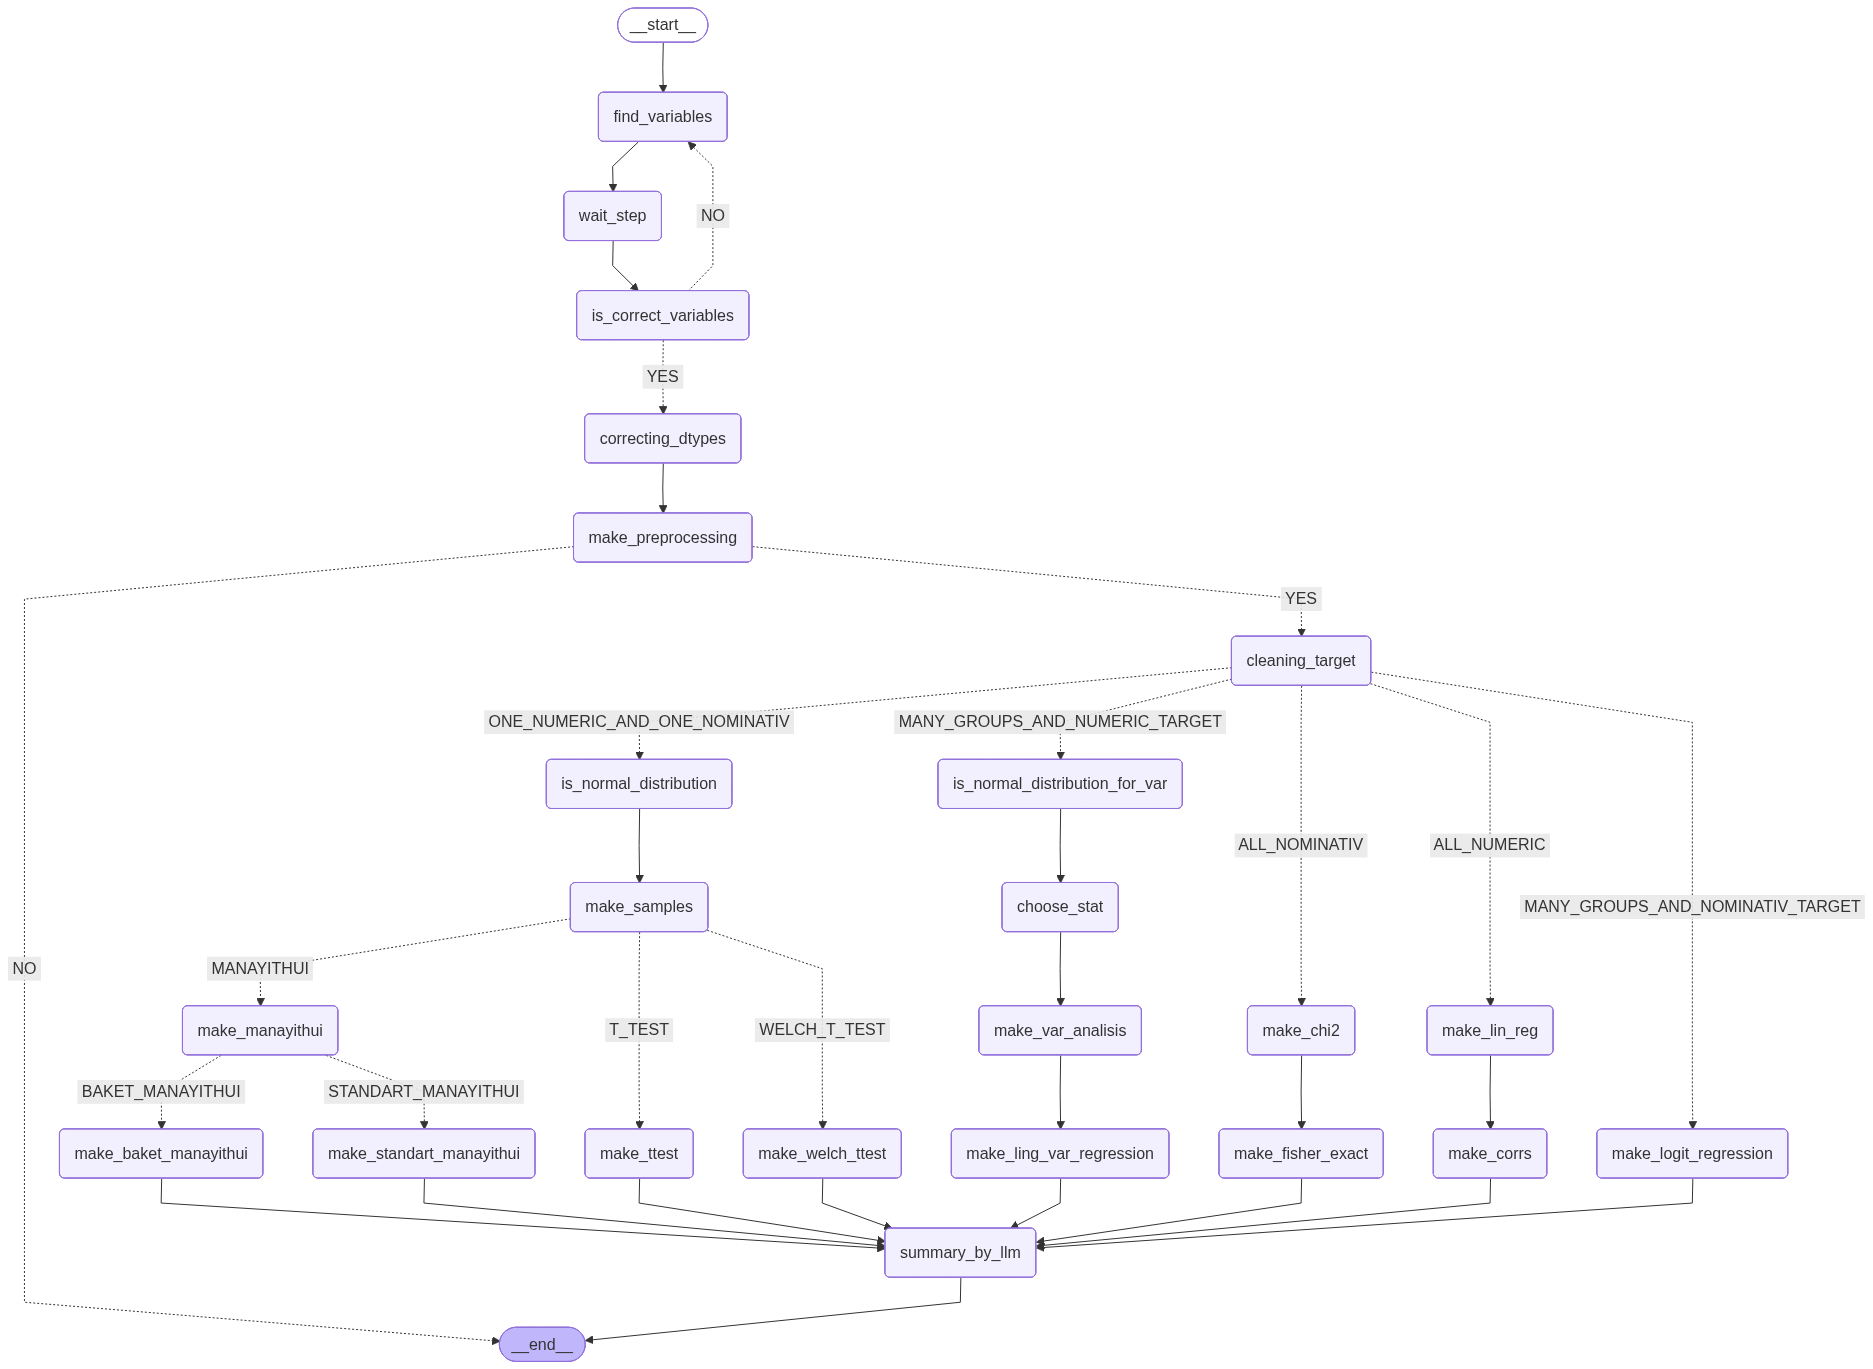

In [ ]:
from PIL import Image

Image.open('/content/graph.png')